In [59]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pmdarima import auto_arima

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.data_validation import validate_data

In [60]:
data_path = project_root/"data"/"interim"/"all_counties_processed_no_fire_2006_2024.csv"
output_dir = project_root/"results"/"sarimax"

counties = [
    "Fresno",
    "Kern",
    "Los Angeles",
    "Orange",
    "San Diego",
    "San Luis Obispo",
    "Tulare",
    "Ventura",
]

feature_columns = [
    "Precipitation",
    "Avg Rel Hum (%)",
    "Avg Wind Speed (mph)",
    "Wind Run (miles)",
    "windeventcount",
    "Avg Soil Temp (F)",
    "AQI_PM25",
    "AQI_PM10",
    "FIRE_Acres_Burned",
    "fungicide_lbs_prd_used",
    "rodent_lbs_prd_used",
]

evaluation_date = "2024-06-01"
horizons = (1,3,6)

In [61]:
data = pd.read_csv(data_path, parse_dates=["Year-Month"])

validate_data(
    data=data,
    required_columns=[
        "County",
        "Year-Month",
        "rate_per_100k",
        "log1p_rate_per_100k",
        *feature_columns,
    ],
    county_col="County",
    date_col="Year-Month"
    )

output_dir.mkdir(parents=True, exist_ok=True)

print(f"Loaded {len(data)} rows of data from {data_path}.")

Required-column check passed.
Duplicate-row check passed.
Monthly-continuity check passed.
Loaded 1768 rows of data from c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\data\interim\all_counties_processed_no_fire_2006_2024.csv.


In [62]:
def prepare_sarimax_data(
        county,
        evaluation_date,
        data=data,
        feature_columns=feature_columns,
        maximum_horizon=6
):
    """
    Separates the training and evaluation periods and 
    standardizes the features for SARIMAX modeling.
    """

    county_data = data[data["County"] == county].sort_values("Year-Month").set_index("Year-Month").copy()
    forecast_origin = pd.Timestamp(evaluation_date)

    training_data = county_data.loc[:forecast_origin]

    future_dates = pd.DatetimeIndex([forecast_origin + pd.DateOffset(months=lead_month) for lead_month in range(1, maximum_horizon + 1)])

    evaluation_data = county_data.loc[future_dates]

    y_train = training_data["log1p_rate_per_100k"]
    X_train = training_data[feature_columns]

    X_future = evaluation_data[feature_columns]

    scaler = StandardScaler()

    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        index=X_train.index,
        columns=feature_columns
    )

    X_future_scaled = pd.DataFrame(
        scaler.transform(X_future),
        index=X_future.index,
        columns=feature_columns
    )

    return {
        "county_data": county_data,
        "training_data": training_data,
        "evaluation_data": evaluation_data,
        "y_train": y_train,
        "X_train_scaled": X_train_scaled,
        "X_future_scaled": X_future_scaled,
        "forecast_origin": forecast_origin,
        "future_dates": future_dates,
        "scaler": scaler
    }

In [63]:
def select_sarimax_order(
        y_train,
        X_train,
        seasonal_period=12,
        trace=False,
):
    automatic_model = auto_arima(
        y=y_train,
        X=X_train,
        seasonal=True,
        m=seasonal_period,
        test="kpss",  # Use KPSS test to determine order of differencing
        seasonal_test="ocsb",  # Use OCSB test to determine seasonal order of differencing
        start_p=0,
        start_q=0,
        max_p=4,
        max_q=4,
        start_P=0,
        start_Q=0,
        max_P=2,
        max_Q=2,
        max_d=2,
        max_D=1,
        stepwise=True,
        information_criterion="aic",
        trace=trace,
    )

    trend = ("c" if automatic_model.with_intercept else "n")

    return {
        "automatic_model": automatic_model,
        "order": automatic_model.order,
        "seasonal_order": automatic_model.seasonal_order,
        "trend": trend
    }

In [64]:
def fit_sarimax(
        y_train,
        X_train,
        order,
        seasonal_order,
        trend
):
    model = SARIMAX(
        endog=y_train,
        exog=X_train,
        order=order,
        seasonal_order=seasonal_order,
        trend=trend,
        enforce_stationarity=True,
        enforce_invertibility=True
    )

    return model.fit(
        disp=False,
        maxiter=200,
    )

In [65]:
def forecast_sarimax(
        fitted_model,
        X_future,
        evaluation_data,
        future_dates
):
    forecast = fitted_model.get_forecast(
        steps=len(future_dates),
        exog=X_future
    )

    predicted_log = forecast.predicted_mean
    confidence_interval_log = forecast.conf_int(alpha=0.05)
    predictions = np.expm1(predicted_log)

    lower_bounds = np.expm1(confidence_interval_log.iloc[:, 0])
    upper_bounds = np.expm1(confidence_interval_log.iloc[:, 1])

    actual_values = evaluation_data["rate_per_100k"]

    return pd.DataFrame({
        "Lead_Month": range(1, len(future_dates) + 1),
        "Target_Date": future_dates,
        "Prediction": predictions,
        "Lower_Bound": lower_bounds,
        "Upper_Bound": upper_bounds,
        "Actual": actual_values,
        "Error": predictions - actual_values
    })

In [66]:
def evaluate_sarimax_horizons(
        prediction_data,
        horizons=(1,3,6)
):
    metric_rows = []

    for horizon in horizons:
        horizon_data = prediction_data.iloc[:horizon]

        rmse = np.sqrt(mean_squared_error(horizon_data["Actual"], horizon_data["Prediction"]))
        mae = mean_absolute_error(horizon_data["Actual"], horizon_data["Prediction"])

        metric_rows.append({
            "Forecast_Horizon": horizon,
            "RMSE": rmse,
            "MAE": mae
        })

    return pd.DataFrame(metric_rows)

In [67]:
def plot_sarimax_horizons(
        county,
        training_data,
        prediction_data,
        metric_data,
        forecast_origin,
        horizons,
        graph_path
):
    fig, axes = plt.subplots(
        len(horizons),
        1,
        figsize=(12, 5 * len(horizons))
    )

    axes = np.atleast_1d(axes)

    for ax, horizon in zip(axes, horizons):
        horizon_predictions = prediction_data.iloc[:horizon]

        line_dates = [forecast_origin, *horizon_predictions["Target_Date"]]
        predicted_values = [training_data["rate_per_100k"].iloc[-1], *horizon_predictions["Prediction"]]
        actual_values = [training_data["rate_per_100k"].iloc[-1], *horizon_predictions["Actual"]]

        ax.plot(
            training_data.tail(36).index,
            training_data["rate_per_100k"].tail(36),
            color="black",
            label="Observed training data"
        )

        ax.plot(
            line_dates,
            predicted_values,
            color="green",
            marker="o",
            label="True values"
        )

        ax.plot(
            line_dates,
            actual_values,
            color="tab:blue",
            marker="o",
            label="SARIMAX predictions"
        )

        ax.fill_between(
            horizon_predictions["Target_Date"],
            horizon_predictions["Lower_Bound"],
            horizon_predictions["Upper_Bound"],
            color="tab:blue",
            alpha=0.15,
            label="95\% confidence interval"
        )

        ax.axvline(
            x=forecast_origin,
            color="gray",
            linestyle=":",
            label="Forecast origin"
        )

        horizon_metrics = metric_data[metric_data["Forecast_Horizon"] == horizon].iloc[0]

        ax.set_title(
            f"{horizon}-Month Horizon | "
            f"RMSE: {horizon_metrics['RMSE']:.3f} | "
            f"MAE: {horizon_metrics['MAE']:.3f}"
        )

        ax.set_xlabel("Month")
        ax.set_ylabel("Rate per 100,000")
        ax.grid(alpha=0.25)
        ax.legend()

    fig.suptitle(f"{county} SARIMAX Forecast Evaluation", fontsize=15)

    plt.tight_layout()

    plt.savefig(graph_path, dpi=180, bbox_inches="tight")

    plt.show()
    plt.close(fig)

<>:54: SyntaxWarning: invalid escape sequence '\%'
<>:54: SyntaxWarning: invalid escape sequence '\%'
C:\Users\austi\AppData\Local\Temp\ipykernel_16696\1258310785.py:54: SyntaxWarning: invalid escape sequence '\%'
  label="95\% confidence interval"


In [68]:
def run_sarimax_county(
    county,
    evaluation_date,
    data=data,
    feature_columns=feature_columns,
    horizons=(1, 3, 6),
    output_dir=output_dir,
    trace=False,
):
    maximum_horizon = max(horizons)

    prepared = prepare_sarimax_data(
        county=county,
        evaluation_date=evaluation_date,
        data=data,
        feature_columns=feature_columns,
        maximum_horizon=maximum_horizon,
    )

    selected_model = select_sarimax_order(
        y_train=prepared["y_train"],
        X_train=prepared["X_train_scaled"],
        seasonal_period=12,
        trace=trace,
    )

    fitted_model = fit_sarimax(
        y_train=prepared["y_train"],
        X_train=prepared["X_train_scaled"],
        order=selected_model["order"],
        seasonal_order=selected_model[
            "seasonal_order"
        ],
        trend=selected_model["trend"],
    )

    prediction_data = forecast_sarimax(
        fitted_model=fitted_model,
        X_future=prepared["X_future_scaled"],
        evaluation_data=prepared["evaluation_data"],
        future_dates=prepared["future_dates"],
    )

    metric_data = evaluate_sarimax_horizons(
        prediction_data=prediction_data,
        horizons=horizons,
    )

    prediction_data.insert(0, "County", county)

    prediction_data["Forecast_Origin"] = prepared["forecast_origin"]

    prediction_data["Order"] = str(selected_model["order"])

    prediction_data["Seasonal_Order"] = str(selected_model["seasonal_order"])

    metric_data.insert(0,"County",county)

    metric_data["Forecast_Origin"] = prepared["forecast_origin"]

    metric_data["Order"] = str(selected_model["order"])

    metric_data["Seasonal_Order"] = str(selected_model["seasonal_order"])

    metric_data["Trend"] = selected_model["trend"]
    metric_data["AIC"] = fitted_model.aic
    metric_data["BIC"] = fitted_model.bic

    county_slug = county.lower().replace(" ","_")

    date_slug = prepared["forecast_origin"].strftime("%Y-%m")

    prediction_path = output_dir/f"{county_slug}_sarimax_predictions_{date_slug}.csv"

    metric_path = output_dir/f"{county_slug}_sarimax_metrics_{date_slug}.csv"

    graph_path = output_dir/f"{county_slug}_sarimax_evaluation_{date_slug}.png"

    prediction_data.to_csv(prediction_path,index=False,date_format="%Y-%m-%d",)

    metric_data.to_csv(metric_path,index=False,date_format="%Y-%m-%d")

    plot_sarimax_horizons(
        county=county,
        training_data=prepared["training_data"],
        prediction_data=prediction_data,
        metric_data=metric_data,
        forecast_origin=prepared["forecast_origin"],
        horizons=horizons,
        graph_path=graph_path,
    )

    return {
        "predictions": prediction_data,
        "metrics": metric_data,
        "fitted_model": fitted_model,
        "automatic_model": selected_model[
            "automatic_model"
        ],
        "scaler": prepared["scaler"],
    }

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=262.045, Time=0.08 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=28.282, Time=1.11 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=126.763, Time=0.69 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=848.057, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=33.884, Time=0.19 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=inf, Time=2.47 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=1.04 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=26.702, Time=0.79 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=28.681, Time=1.80 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=2.18 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=246.024, Time=0.52 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=24.719, Time=0.88 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=31.449, Time=0.34 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=1.25 sec
 ARIMA(2,0,0)(0,0,2)[12] intercept   : AIC=26.635, Time

c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


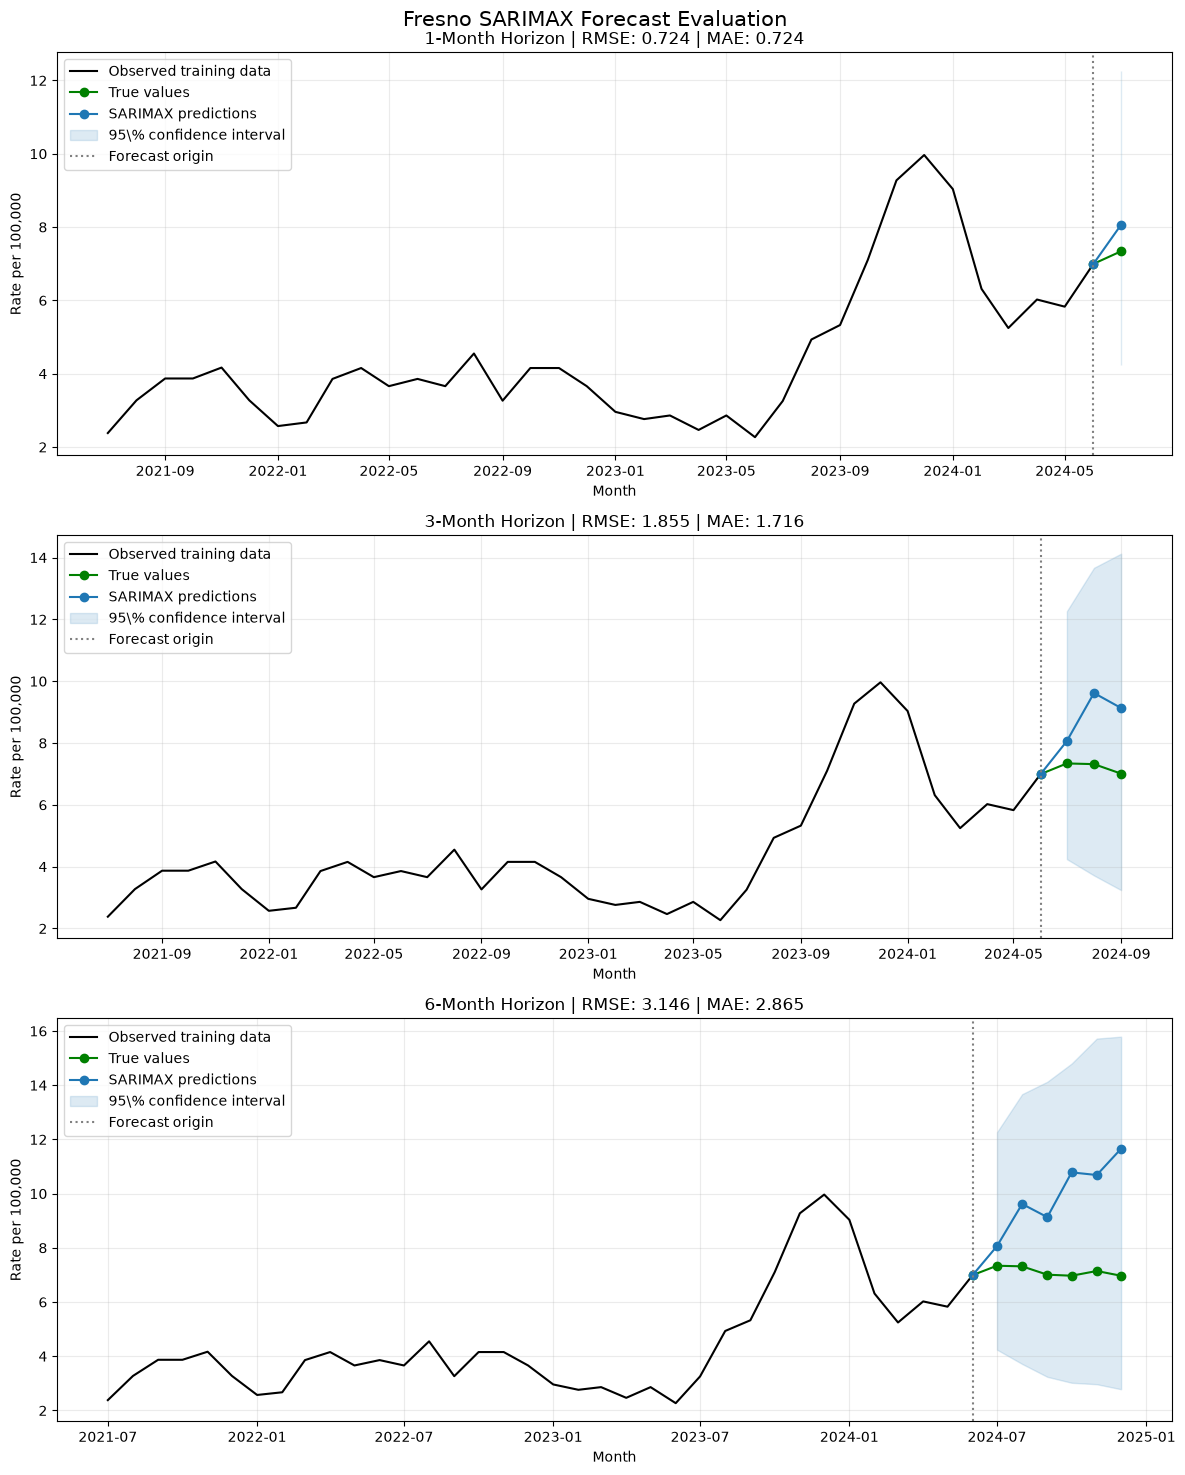

,County,Lead_Month,Target_Date,Prediction,Lower_Bound,Upper_Bound,Actual,Error,Forecast_Origin,Order,Seasonal_Order
2024-07-01,Fresno,1,2024-07-01,7.340180,4.243481,12.265731,8.063874,-0.723693,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
2024-08-01,Fresno,2,2024-08-01,7.317627,3.716183,13.669261,9.618355,-2.300728,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
2024-09-01,Fresno,3,2024-09-01,7.009671,3.241062,14.127066,9.132580,-2.122909,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
2024-10-01,Fresno,4,2024-10-01,6.971645,3.022090,14.799525,10.784217,-3.812572,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
2024-11-01,Fresno,5,2024-11-01,7.145629,2.968142,15.720990,10.687061,-3.541433,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
2024-12-01,Fresno,6,2024-12-01,6.970084,2.782965,15.791653,11.658613,-4.688529,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"


,County,Forecast_Horizon,RMSE,MAE,Forecast_Origin,Order,Seasonal_Order,Trend,AIC,BIC
0,Fresno,1,0.723693,0.723693,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)",c,24.564451,78.494659
1,Fresno,3,1.855067,1.715777,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)",c,24.564451,78.494659
2,Fresno,6,3.145992,2.864977,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)",c,24.564451,78.494659


In [69]:
fresno_results = run_sarimax_county(
    county="Fresno",
    evaluation_date=evaluation_date,
    data=data,
    feature_columns=feature_columns,
    horizons=horizons,
    output_dir=output_dir,
    trace=True,
)

display(fresno_results["predictions"])
display(fresno_results["metrics"])

In [70]:
print(fresno_results["fitted_model"].summary())

                                     SARIMAX Results                                      
Dep. Variable:                log1p_rate_per_100k   No. Observations:                  215
Model:             SARIMAX(1, 0, 1)x(0, 0, 1, 12)   Log Likelihood                   3.718
Date:                            Tue, 29 Sep 2026   AIC                             24.564
Time:                                    02:15:28   BIC                             78.495
Sample:                                08-01-2006   HQIC                            46.355
                                     - 06-01-2024                                         
Covariance Type:                              opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                  0.1988      0.065      3.061      0.002       0.072       0.326

Running Fresno...


c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


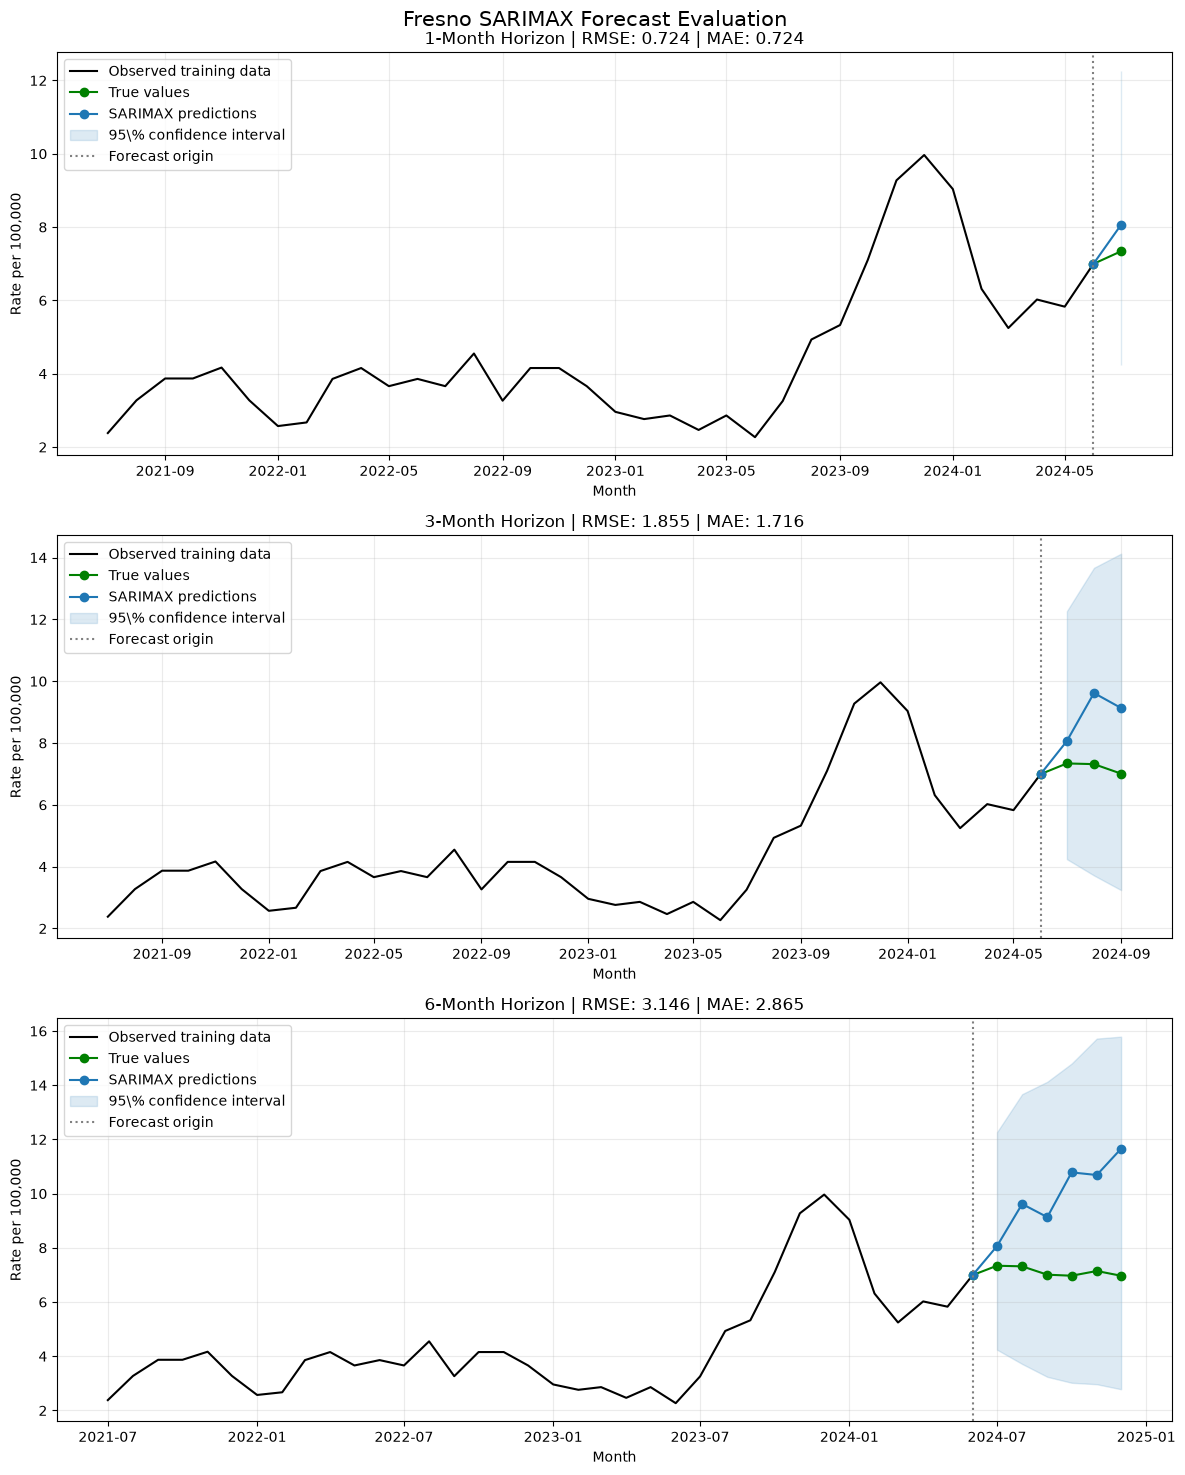

Running Kern...


c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


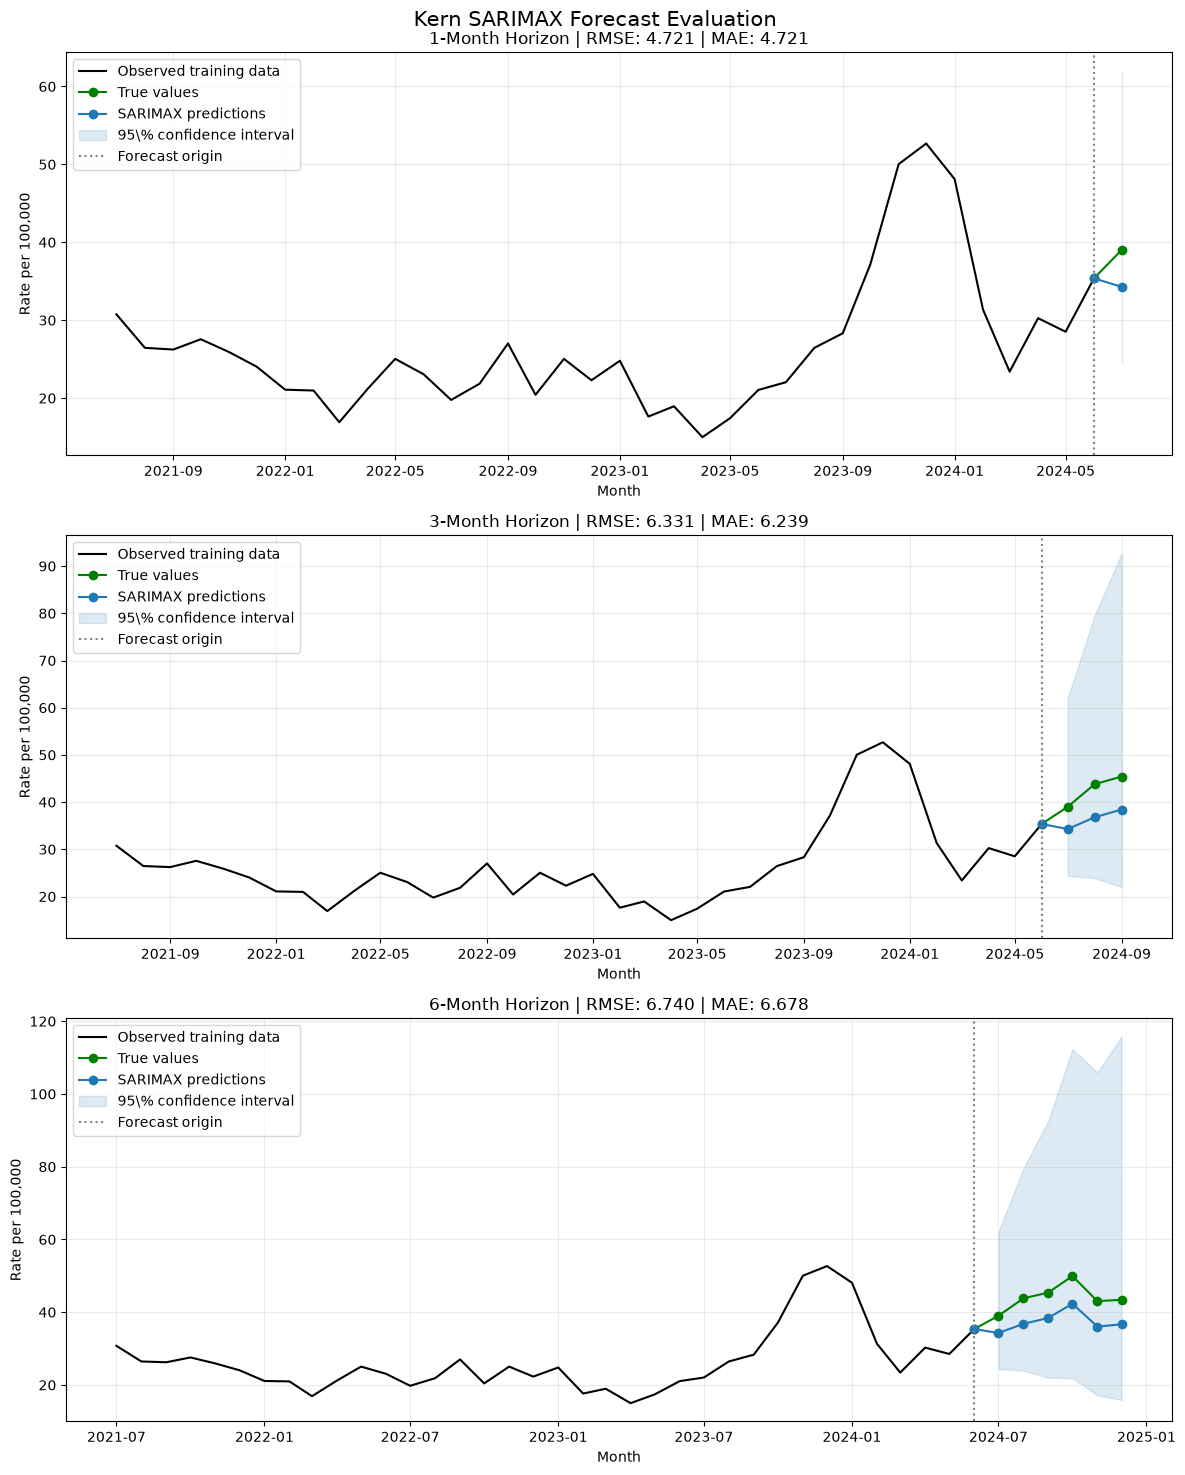

Running Los Angeles...


c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


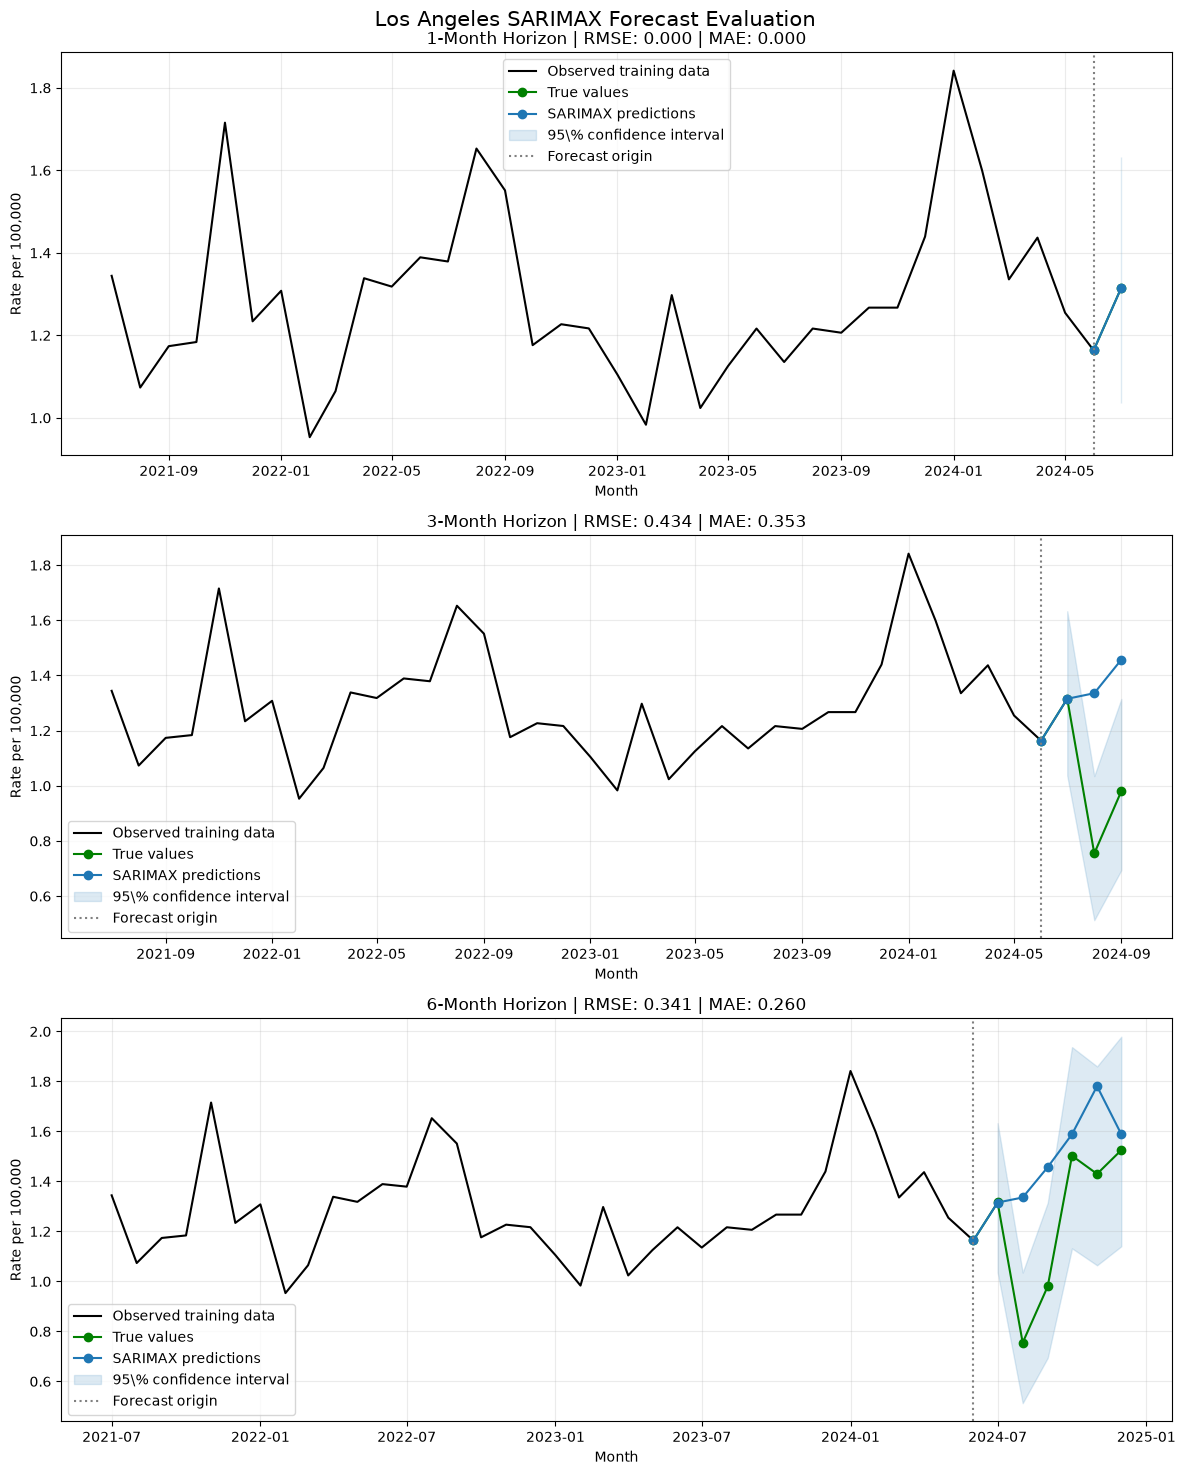

Running Orange...


c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found.

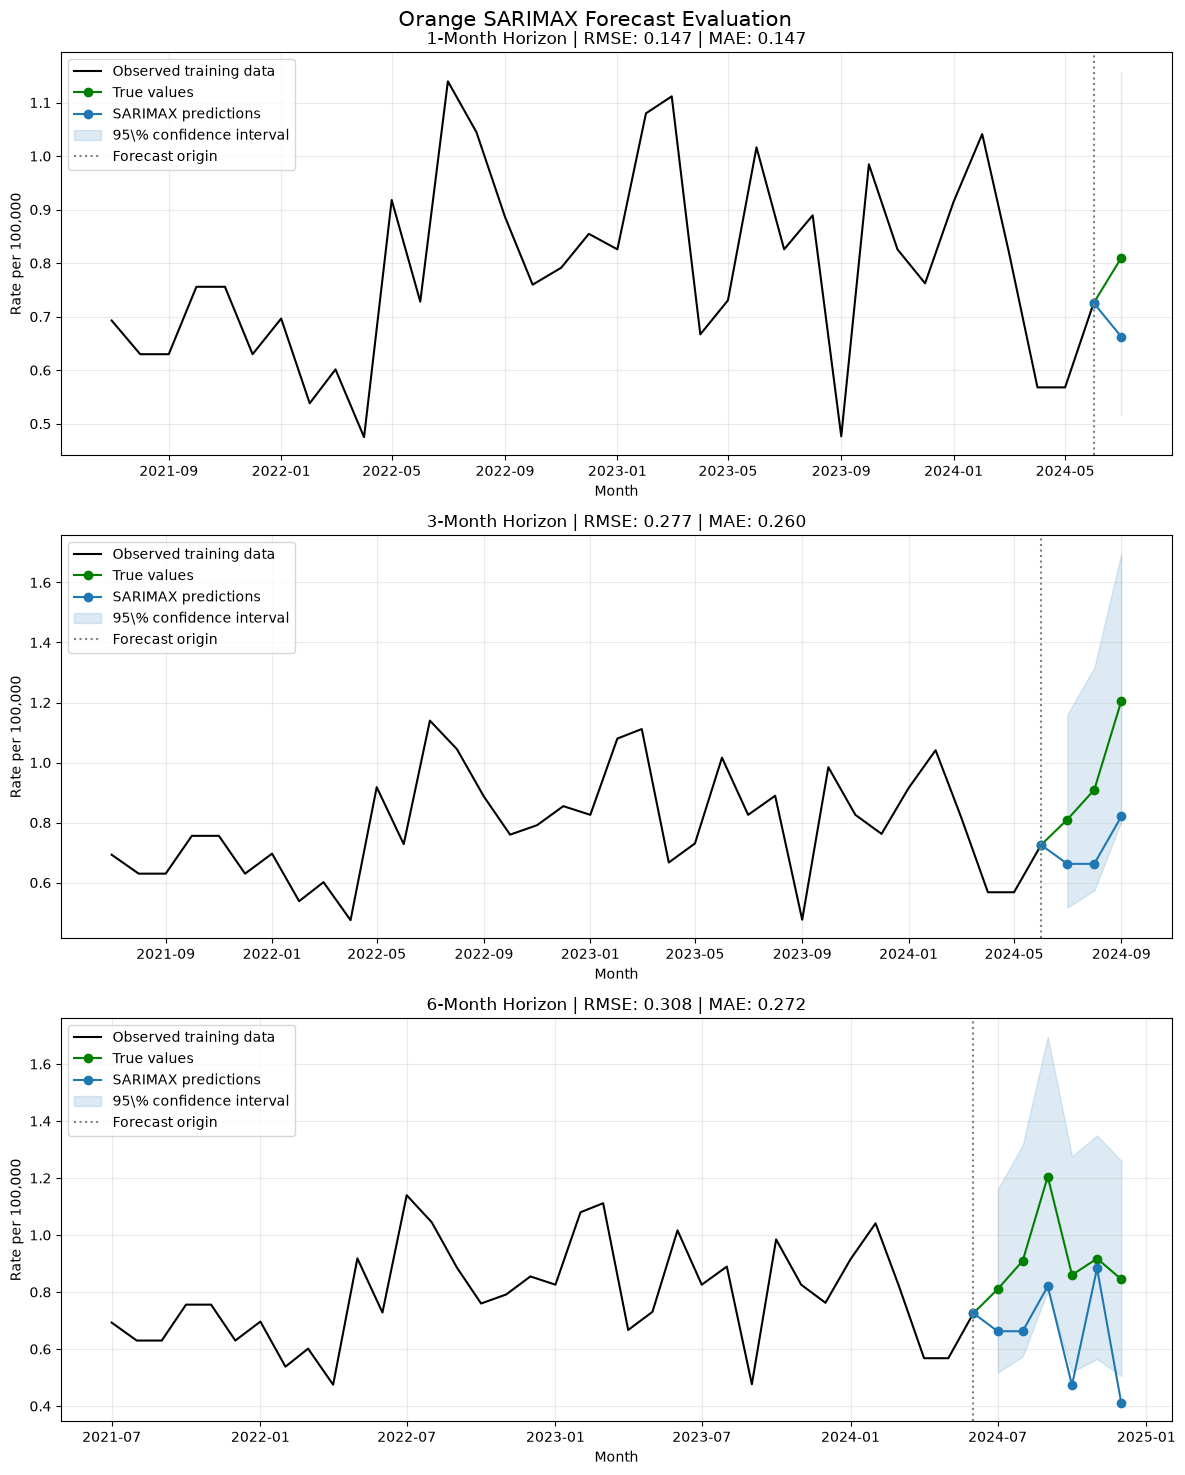

Running San Diego...


c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


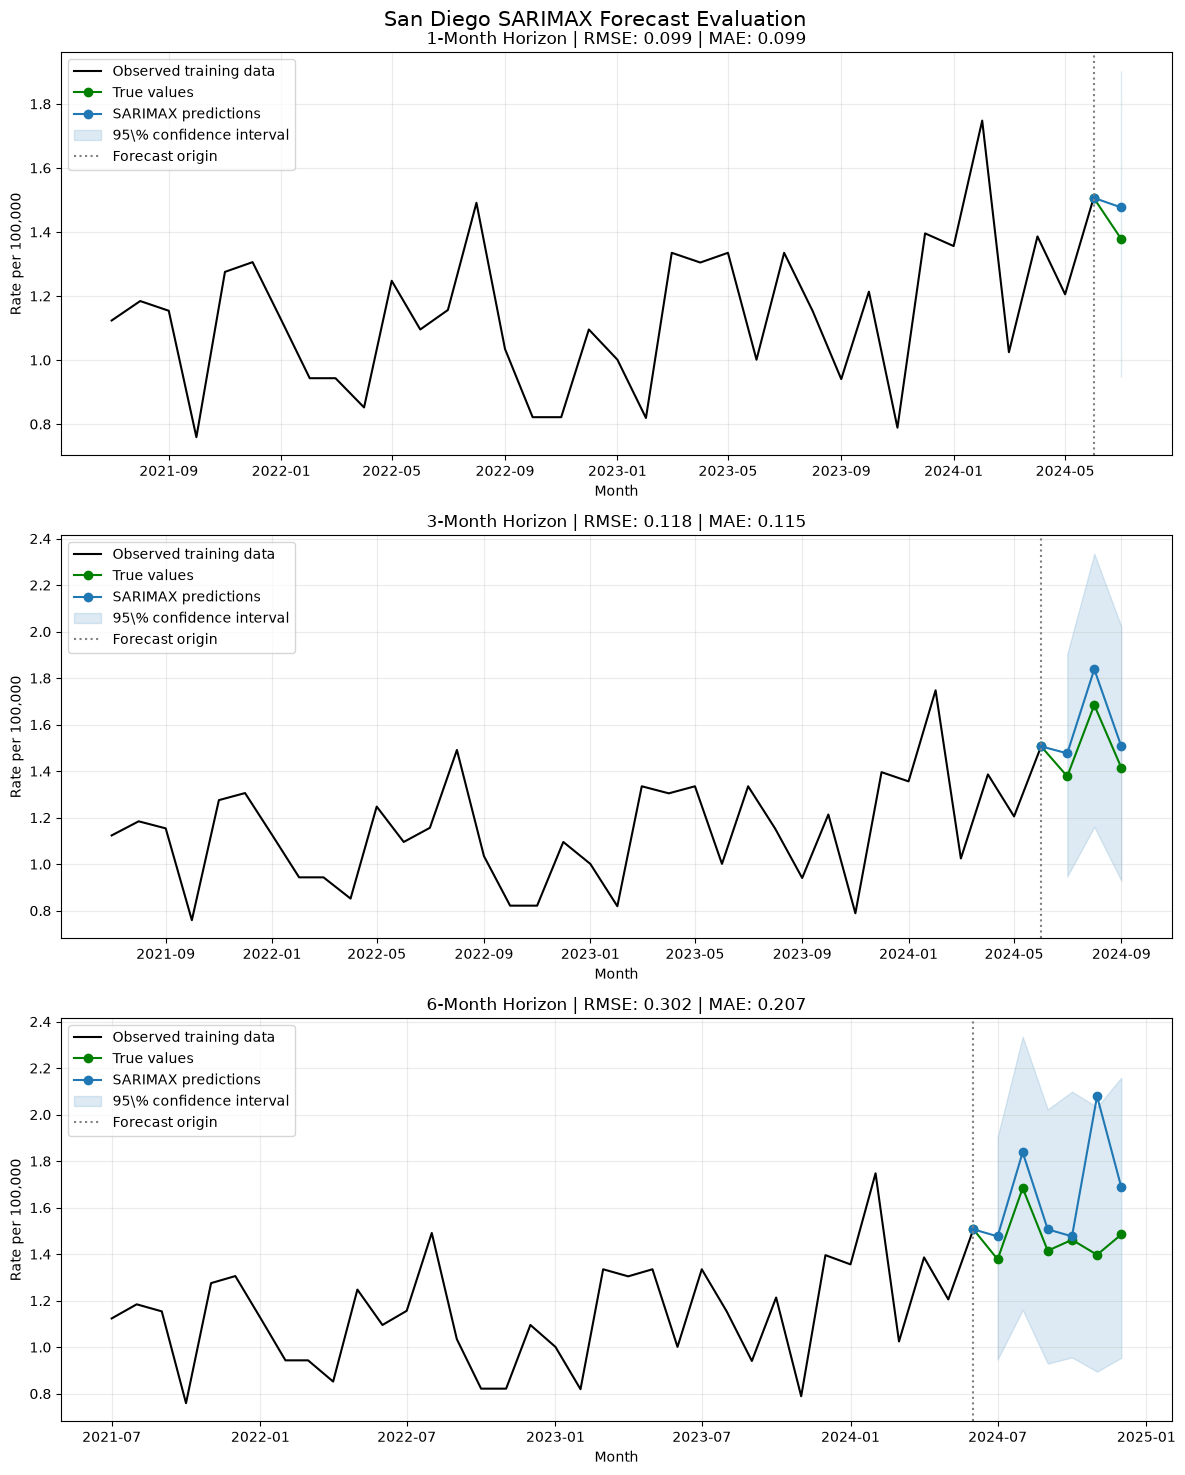

Running San Luis Obispo...


c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


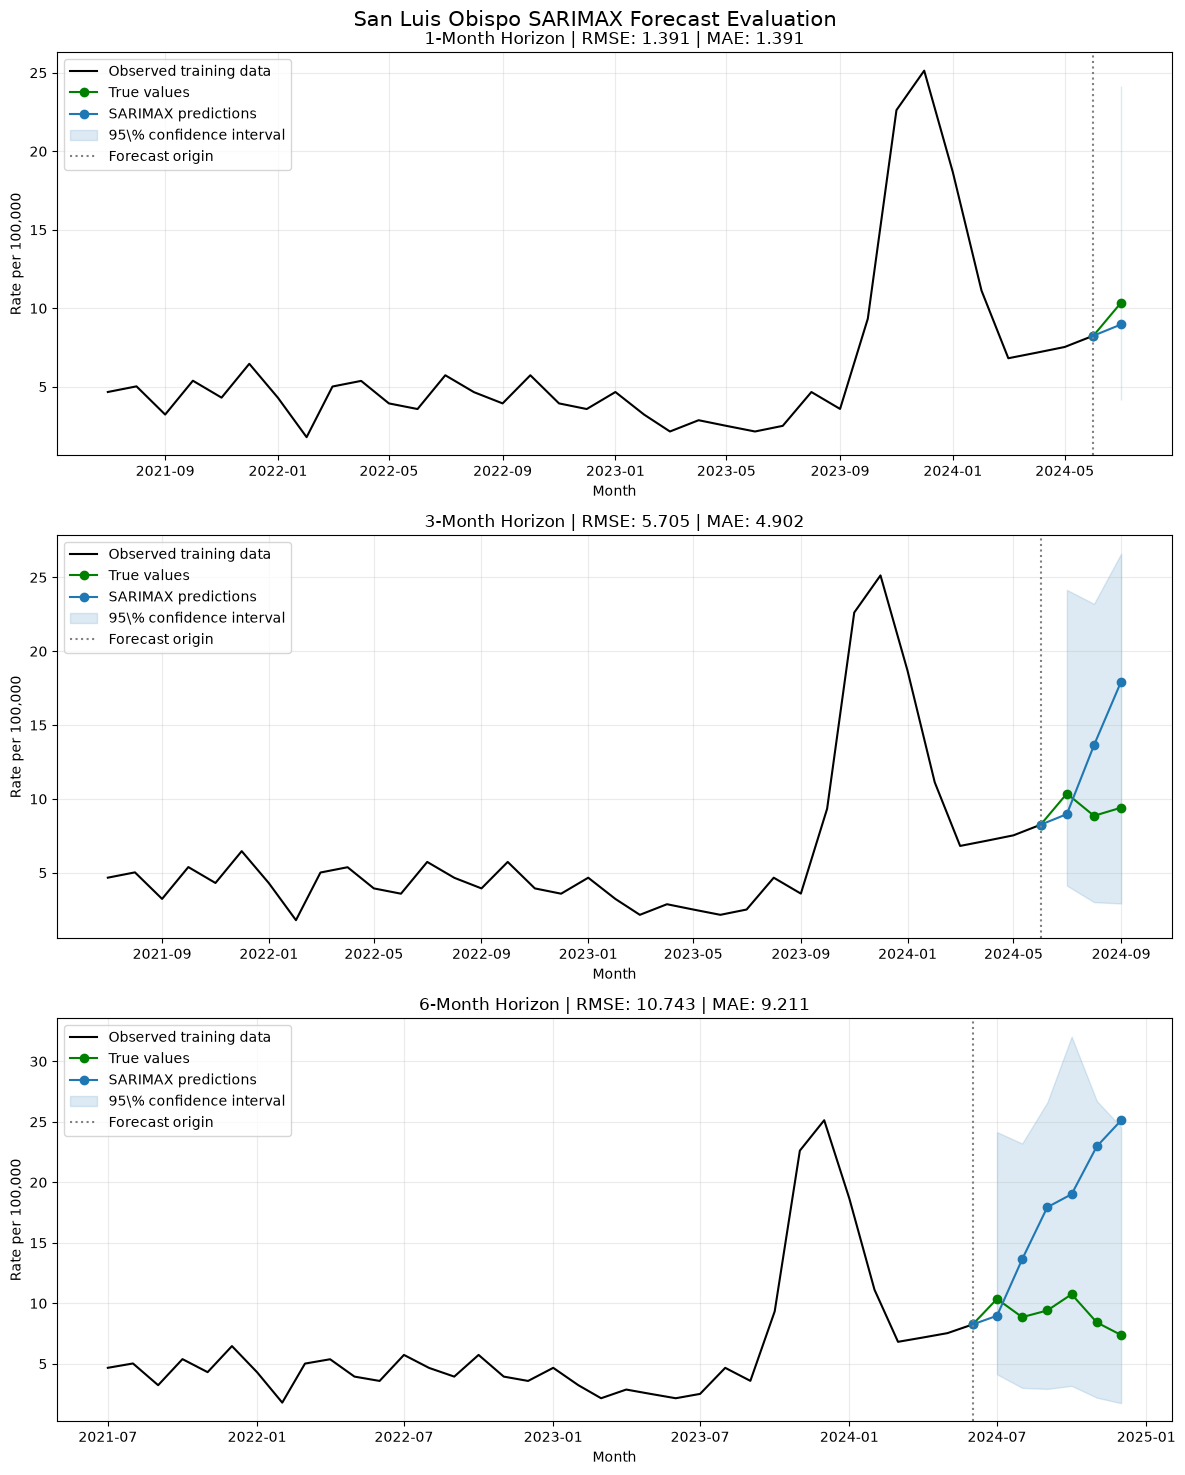

Running Tulare...


c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


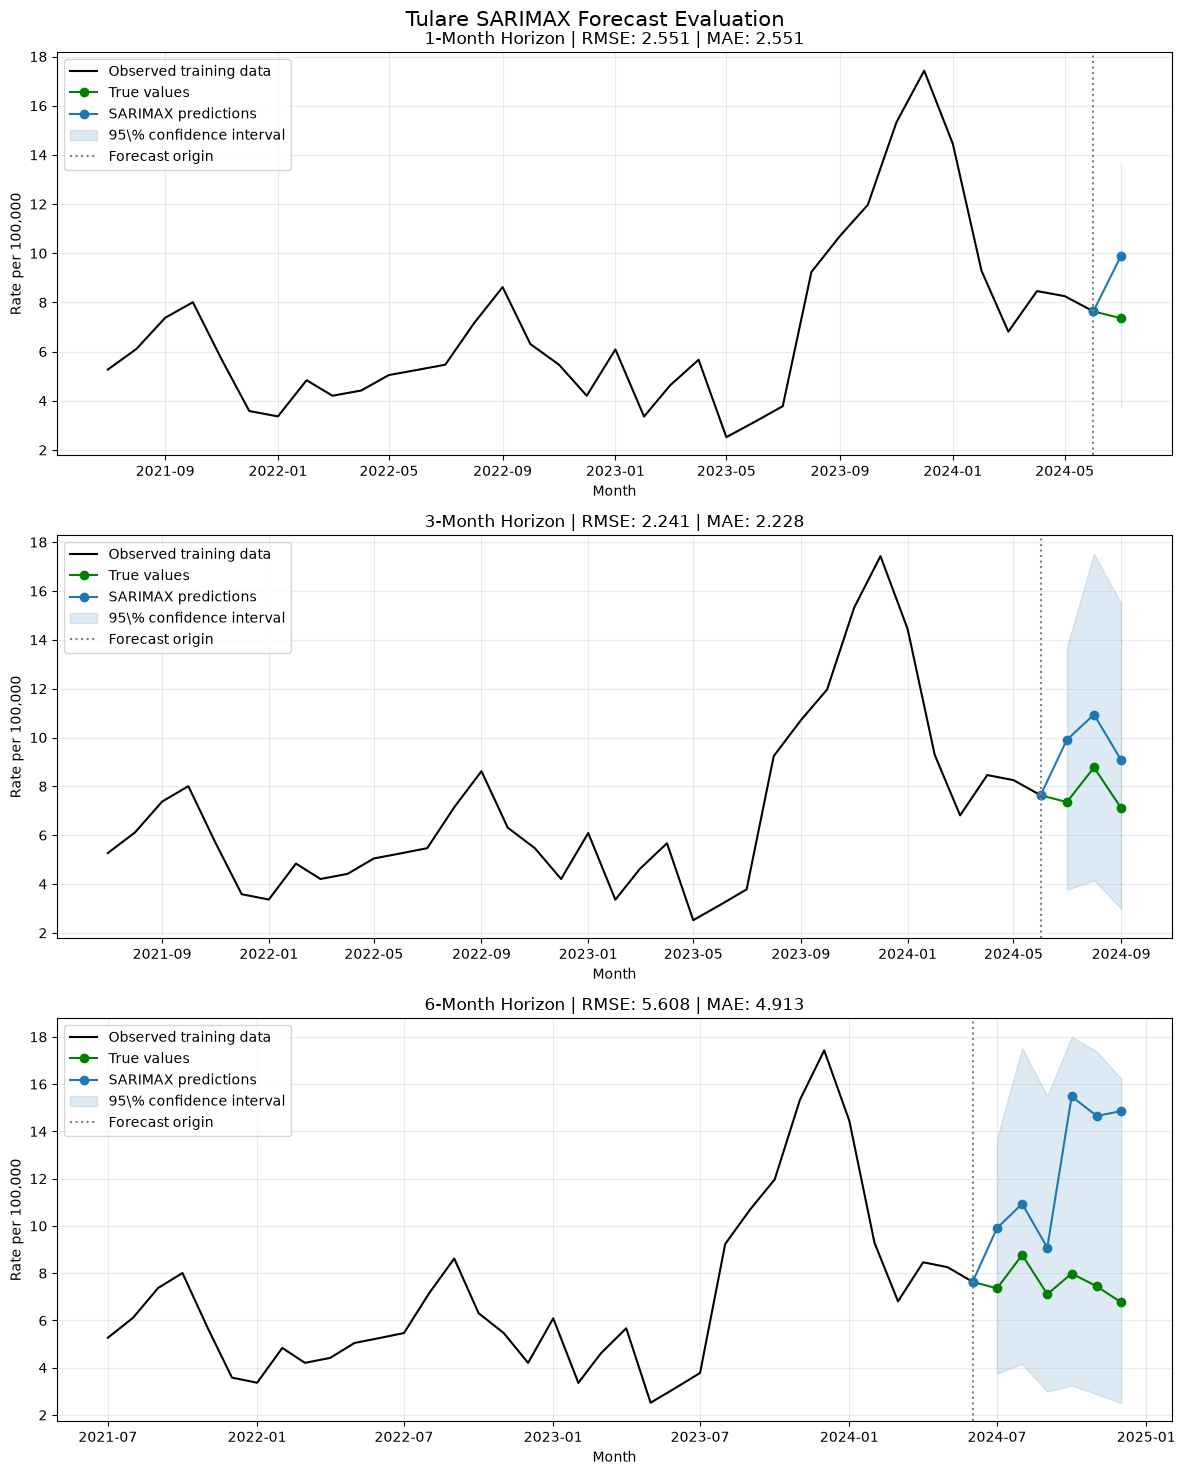

Running Ventura...


c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\.venv313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


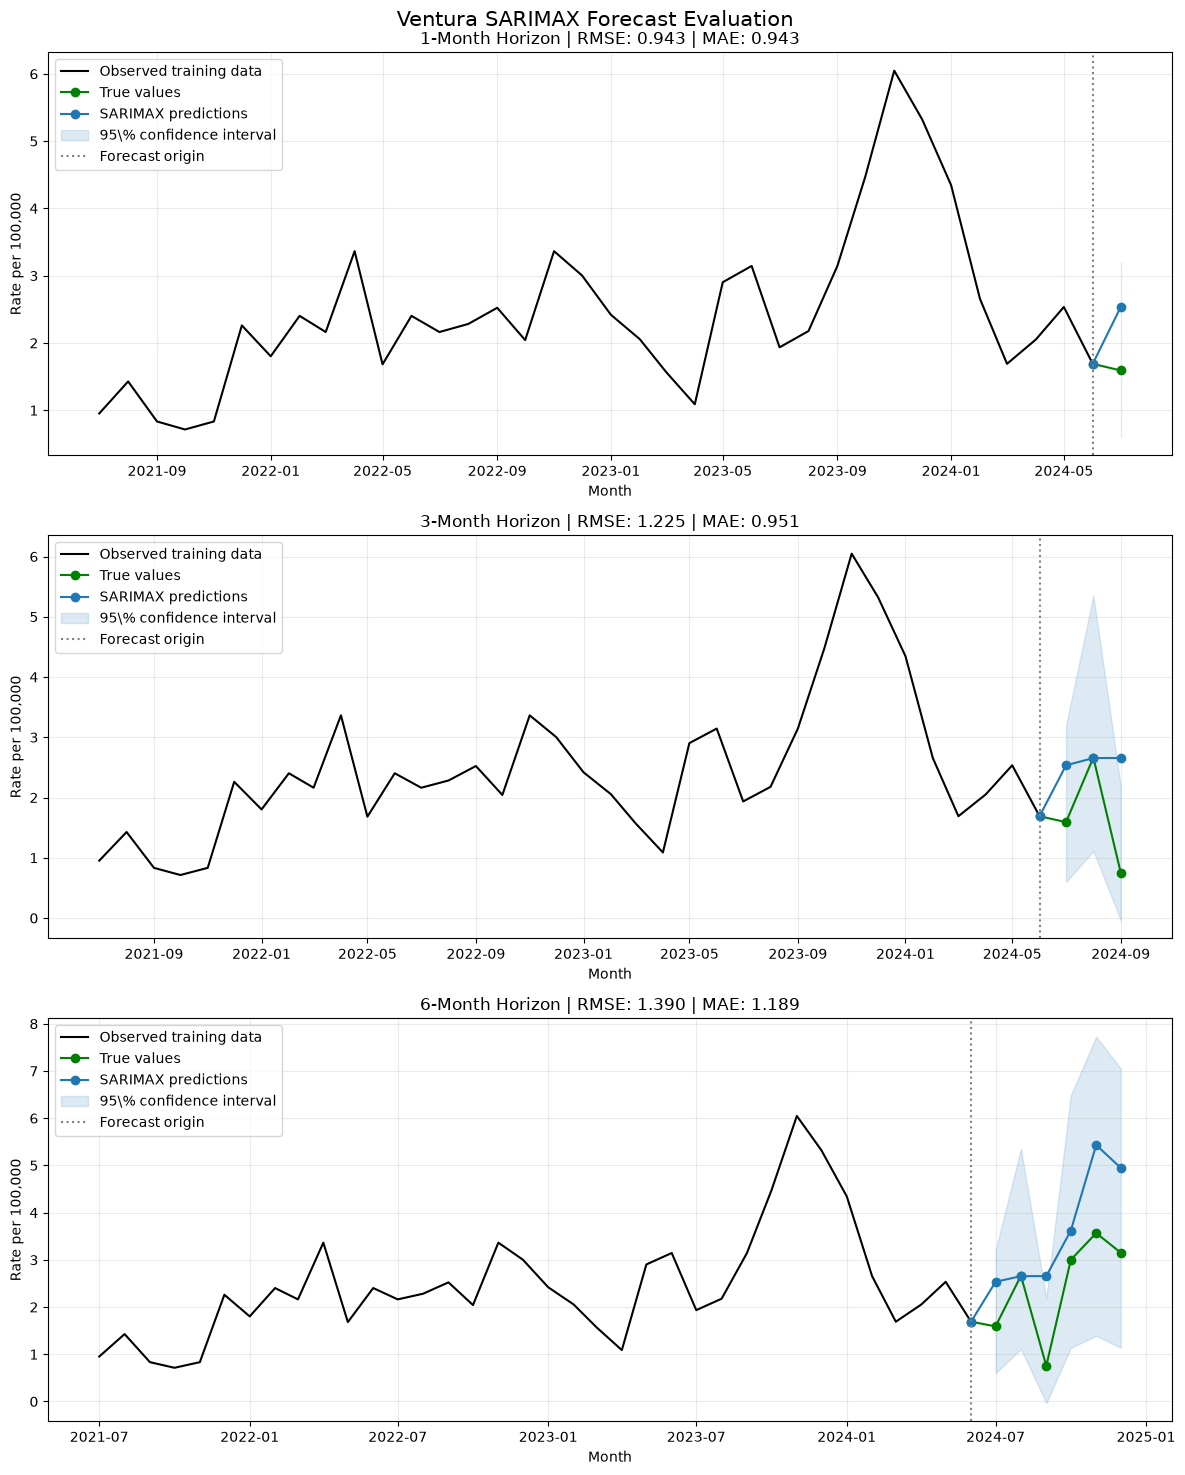

,County,Lead_Month,Target_Date,Prediction,Lower_Bound,Upper_Bound,Actual,Error,Forecast_Origin,Order,Seasonal_Order
0,Fresno,1,2024-07-01,7.340180,4.243481,12.265731,8.063874,-0.723693,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
1,Fresno,2,2024-08-01,7.317627,3.716183,13.669261,9.618355,-2.300728,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
2,Fresno,3,2024-09-01,7.009671,3.241062,14.127066,9.132580,-2.122909,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
3,Fresno,4,2024-10-01,6.971645,3.022090,14.799525,10.784217,-3.812572,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
4,Fresno,5,2024-11-01,7.145629,2.968142,15.720990,10.687061,-3.541433,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
5,Fresno,6,2024-12-01,6.970084,2.782965,15.791653,11.658613,-4.688529,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)"
6,Kern,1,2024-07-01,39.007498,24.394387,62.029671,34.286871,4.720626,2024-06-01,"(1, 1, 0)","(0, 0, 0, 12)"
7,Kern,2,2024-08-01,43.803317,23.926632,79.529821,36.790357,7.012960,2024-06-01,"(1, 1, 0)","(0, 0, 0, 12)"
8,Kern,3,2024-09-01,45.406938,21.999402,92.637386,38.423065,6.983873,2024-06-01,"(1, 1, 0)","(0, 0, 0, 12)"
9,Kern,4,2024-10-01,49.944325,21.897405,112.345779,42.341565,7.602760,2024-06-01,"(1, 1, 0)","(0, 0, 0, 12)"


,County,Forecast_Horizon,RMSE,MAE,Forecast_Origin,Order,Seasonal_Order,Trend,AIC,BIC
0,Fresno,1,0.723693,0.723693,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)",c,24.564451,78.494659
1,Fresno,3,1.855067,1.715777,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)",c,24.564451,78.494659
2,Fresno,6,3.145992,2.864977,2024-06-01,"(1, 0, 1)","(0, 0, 1, 12)",c,24.564451,78.494659
3,Kern,1,4.720626,4.720626,2024-06-01,"(1, 1, 0)","(0, 0, 0, 12)",n,7.862390,51.620078
4,Kern,3,6.330887,6.239153,2024-06-01,"(1, 1, 0)","(0, 0, 0, 12)",n,7.862390,51.620078
5,Kern,6,6.740078,6.677926,2024-06-01,"(1, 1, 0)","(0, 0, 0, 12)",n,7.862390,51.620078
6,Los Angeles,1,0.000223,0.000223,2024-06-01,"(1, 1, 1)","(0, 0, 0, 12)",c,-528.236890,-477.747250
7,Los Angeles,3,0.433946,0.352684,2024-06-01,"(1, 1, 1)","(0, 0, 0, 12)",c,-528.236890,-477.747250
8,Los Angeles,6,0.341469,0.259782,2024-06-01,"(1, 1, 1)","(0, 0, 0, 12)",c,-528.236890,-477.747250
9,Orange,1,0.147452,0.147452,2024-06-01,"(2, 1, 2)","(0, 0, 0, 12)",c,-386.276554,-329.054962


In [71]:
all_prediction_results = []
all_metric_results = []
county_models = {}

for county in counties:
    print(f"Running {county}...")

    results = run_sarimax_county(
        county=county,
        evaluation_date=evaluation_date,
        data=data,
        feature_columns=feature_columns,
        horizons=horizons,
        output_dir=output_dir,
        trace=False,
    )

    all_prediction_results.append(
        results["predictions"]
    )

    all_metric_results.append(
        results["metrics"]
    )

    county_models[county] = results

all_predictions = pd.concat(
    all_prediction_results,
    ignore_index=True,
)

all_metrics = pd.concat(
    all_metric_results,
    ignore_index=True,
)

date_slug = pd.Timestamp(
    evaluation_date
).strftime("%Y-%m")

all_predictions.to_csv(
    output_dir
    / f"all_counties_sarimax_predictions_{date_slug}.csv",
    index=False,
    date_format="%Y-%m-%d",
)

all_metrics.to_csv(
    output_dir
    / f"all_counties_sarimax_metrics_{date_slug}.csv",
    index=False,
    date_format="%Y-%m-%d",
)

display(all_predictions)
display(all_metrics)

In [72]:
metric_summary = all_metrics.pivot(
    index="County",
    columns="Forecast_Horizon",
    values=["RMSE", "MAE"],
)

display(metric_summary)

metric_summary.to_csv(
    output_dir
    / f"sarimax_metric_summary_{date_slug}.csv"
)

RMSE                            MAE                    
Forecast_Horizon         1         3          6         1         3         6
County                                                                       
Fresno            0.723693  1.855067   3.145992  0.723693  1.715777  2.864977
Kern              4.720626  6.330887   6.740078  4.720626  6.239153  6.677926
Los Angeles       0.000223  0.433946   0.341469  0.000223  0.352684  0.259782
Orange            0.147452  0.277318   0.308334  0.147452  0.259675  0.272435
San Diego         0.098841  0.118135   0.302289  0.098841  0.114840  0.207348
San Luis Obispo   1.391210  5.704764  10.742643  1.391210  4.902192  9.211085
Tulare            2.550942  2.241347   5.607921  2.550942  2.228271  4.913406
Ventura           0.943463  1.225361   1.390204  0.943463  0.950875  1.189177